In [ ]:
# JacobNet New York ISO Market Bidder Version 3.0

# Libraries
import torch as torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import subprocess
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm

# CUDA utilization check
print("Torch version:", torch.__version__)
print("CUDA available." if torch.cuda.is_available() else "CUDA not available.")
print("CUDA version:", torch.version.cuda)
print("CUDA Device:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU, will use CPU.")

Torch version: 2.7.0+cu126
CUDA available.
CUDA version: 12.6
CUDA Device: NVIDIA T1200 Laptop GPU


In [5]:
# Import data with pandas
def data_import(include_target=True, year=2015):
    # Use year tag to determine files
    if year == 2015:
        load_forecast = pd.read_csv('data/DAM_NYISO_LoadForecast_2015.csv') 
        da_prices = pd.read_csv('data/DAM_NYISO_Zonal_LBMP_2015.csv')
        rt_prices = pd.read_csv('data/RTM_NYISO_Zonal_LBMP_2015.csv')
    elif year == 2016:
        load_forecast = pd.read_csv('data/DAM_NYISO_LoadForecast_2016.csv') 
        da_prices = pd.read_csv('data/DAM_NYISO_Zonal_LBMP_2016.csv')
        rt_prices = pd.read_csv('data/RTM_NYISO_Zonal_LBMP_2016.csv')
    else:
        raise ValueError("Data year error.")

    # Format strings to standardize
    load_forecast.columns = load_forecast.columns.str.strip().str.lower()
    da_prices.columns = da_prices.columns.str.strip().str.lower()
    rt_prices.columns = rt_prices.columns.str.strip().str.lower()

    # Format date/time data to standardize
    load_forecast['eastern date hour'] = pd.to_datetime(load_forecast['eastern date hour'], format='%m/%d/%y %H:%M')
    da_prices['eastern date hour'] = pd.to_datetime(da_prices['eastern date hour'], format='%Y/%m/%d %H:%M:%S')
    rt_prices['eastern date hour'] = pd.to_datetime(rt_prices['eastern date hour'], format='%Y/%m/%d %H:%M:%S')

    # Format zone names to standardize
    load_forecast['zone name'] = load_forecast['zone name'].str.strip()
    da_prices['zone name'] = da_prices['zone name'].str.strip()
    rt_prices['zone name'] = rt_prices['zone name'].str.strip()

    # Merge into one data frame for use with data loader
    merged_data = load_forecast.merge(da_prices, on=['eastern date hour', 'zone name'])
    merged_data = merged_data.merge(rt_prices, on=['eastern date hour', 'zone name'])

    # Feature engineer hour and weekday for extra FFNN inputs
    merged_data['hour'] = merged_data['eastern date hour'].dt.hour
    merged_data['weekday'] = merged_data['eastern date hour'].dt.weekday

    # Add a target column for the 2015 training
    if include_target:
        merged_data['da_lower'] = (merged_data['dam zonal lbmp'] < merged_data['twi zonal lbmp']).astype(int)

    # List of the dataframe columns to return
    feature_cols = [
        'dam forecast load',
        'dam zonal lbmp',
        'dam zonal losses',
        'dam zonal congestion',
        'hour',
        'weekday'
    ]

    return merged_data, feature_cols, 'da_lower'

In [6]:
# Class for training dataset
class NYISOData(Dataset):
    def __init__(self, dataframe, feature_cols, target_col):
        self.X = torch.tensor(dataframe[feature_cols].values, dtype=torch.float32)
        self.Y = torch.tensor(dataframe[target_col].values, dtype=torch.float32).unsqueeze(1)

    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, idx):
        return self.X[idx], self.Y[idx]
    
# Class for simulation dataset
class TestNYISOData(Dataset):
    def __init__(self, dataframe, feature_cols):
        self.X = torch.tensor(dataframe[feature_cols].values, dtype=torch.float32)

    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, idx):
        return self.X[idx]

In [24]:
# Create model
class JacobNet(nn.Module):
    def __init__(self, input_dim):
        super(JacobNet, self).__init__()
        self.model = nn.Sequential(
            # if start overfitting add dropout later
            # consider embedding later

            # Initial
            nn.Linear(input_dim, 1500),
            nn.BatchNorm1d(1500),
            nn.ReLU(),

            # Layer 1
            nn.Linear(1500, 1400),
            nn.BatchNorm1d(1400),
            nn.ReLU(),

            # Layer 2
            nn.Linear(1400, 1200),
            nn.BatchNorm1d(1200),
            nn.ReLU(),

            # Layer 3
            nn.Linear(1200, 1000),
            nn.BatchNorm1d(1000),
            nn.ReLU(),

            # Layer 4
            nn.Linear(1000, 800),
            nn.BatchNorm1d(800),
            nn.ReLU(),
            
            # Layer 5
            nn.Linear(800, 600),
            nn.BatchNorm1d(600),
            nn.ReLU(),

            # Layer 6
            nn.Linear(600, 400),
            nn.BatchNorm1d(400),
            nn.ReLU(),

            # Layer 7
            nn.Linear(400, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),

            # Layer 8
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),

            # Layer 9
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),

            # Activation
            nn.Linear(64, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.model(x)
    
# Metrics definiton for model
def metrics(preds, labels):
    # Get predictions and true values
    preds = (preds >= 0.5).float()
    labels = labels.float()

    # Calculate metrics
    correct = (preds == labels).sum().item()
    total = labels.size(0)
    accuracy = correct/total
    true_positive = ((preds == 1) & (labels == 1)).sum().item()
    predicted_positive = (preds == 1).sum().item()
    actual_positive = (labels == 1).sum().item()

    if predicted_positive > 0:
        precision = true_positive/predicted_positive
    else:
        precision = 0.0

    if actual_positive > 0:
        recall = true_positive/actual_positive
    else:
        recall = 0.0

    return accuracy, precision, recall

In [25]:
# Model training, evaluation, bidding simulation

# Training
def train(model, train_loader, optimizer, criterion, device, epoch, epochs):
    model.train()
    running_loss = 0.0

    for inputs, targets in tqdm(train_loader, desc=f"Training JacobNet, Epoch {epoch+1}/{epochs}", leave=False):
        inputs, targets = inputs.to(device), targets.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()*inputs.size(0)
    
    return running_loss/len(train_loader.dataset)

# Evaluation
def evaluate(model, val_loader, device):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for inputs, targets in tqdm(val_loader, desc="Evaluating JacobNet", leave=False):
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)

            all_preds.append(outputs)
            all_labels.append(targets)

    all_preds = torch.cat(all_preds, dim=0)
    all_labels = torch.cat(all_labels, dim=0)

    acc, prec, rec = metrics(all_preds, all_labels)

    return acc, prec, rec

# Simulation
def bidding_sim(test_data, model, feature_cols, device, bid_threshold=0.6, output=False):
    # Load input data
    test_dataset = TestNYISOData(test_data, feature_cols)
    test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

    # Ensure model is evaluating, array to hold predictions
    model.eval()
    preds = []

    # Get predictions from model
    with torch.no_grad():
        for inputs in tqdm(test_loader, desc="JacobNet Predicting...", leave=False):
            inputs = inputs.to(device)
            outputs = model(inputs)
            preds.append(outputs.cpu())
    preds = torch.cat(preds, dim=0).squeeze().numpy()

    # Make column for model bid decisions with confidence threshold
    test_data['prediction'] = preds
    test_data['make_bid'] = (test_data['prediction'] > bid_threshold).astype(int)

    # Bid price and profit calculation
    bid_increment = 1.0
    total_profit = 0.0

    test_data['bid_price'] = test_data['dam zonal lbmp'] + bid_increment
    test_data['da_price'] = test_data['dam zonal lbmp']
    test_data['rt_price'] = test_data['twi zonal lbmp']
    test_data['profit'] = 0.0
    test_data['date'] = test_data['eastern date hour'].dt.date

    # Yearly trading loop
    for day, day_df in test_data.groupby('date'):
        # Import bids and sort against confidence
        day_df = day_df.copy()
        day_bids = day_df[day_df['make_bid'] == 1]
        day_bids = day_bids.sort_values(by='prediction', ascending=False)

        # Per day bidding strategy
        spent_today = 0.0
        daily_budget = 250000
        for idx, row in day_bids.iterrows():
            if spent_today + row['bid_price'] <= daily_budget:
                spent_today += row['bid_price']

                # Profit = RT - DA
                bid_profit = row['rt_price'] - row['da_price']
                test_data.at[idx, 'profit'] = bid_profit
                total_profit += bid_profit
            else:
                # Budget exceeded
                break

    # Save predictions for Kaggle competition
    prediction_df = pd.DataFrame({
        'id': np.arange(len(test_data)),
        'Eastern Date Hour': test_data['eastern date hour'],
        'Zone Name': test_data['zone name'],
        'Zone PTID': test_data['zone ptid_x'],
        'DA Lower': test_data['make_bid'],
        'Bid Price': test_data['bid_price']
    })

    #print(prediction_df)
    #prediction_df = prediction_df.head(96624)

    prediction_df["Eastern Date Hour"] = pd.to_datetime(prediction_df["Eastern Date Hour"])
    prediction_df["Eastern Date Hour"] = prediction_df["Eastern Date Hour"].dt.strftime("%Y/%m/%d %H:%M:%S")

    if output:
        prediction_df.to_csv('output/prediction.csv', index=False, quoting=1)
        print(f"Prediction file saved.")

    return total_profit

def optimal_threshold(model, data, device, feature_cols, lower=0.45, upper=0.65, inc=0.01):
    # Test range of total profit across varying bid confidence thresholds
    thresh_range = np.arange(lower, upper, inc)
    profits_arr = []

    for i in thresh_range:
        profit = bidding_sim(data, model, feature_cols, device, bid_threshold=i)
        profits_arr.append(profit)
    profits_arr = np.array(profits_arr)

    best_idx = np.argmax(profits_arr)
    best_threshold = thresh_range[best_idx]
    best_profit = profits_arr[best_idx]

    # Plot results
    plt.figure(figsize=(8,5))
    plt.plot(thresh_range, profits_arr)
    plt.title('Profit vs Threshold')
    plt.xlabel('Threshold')
    plt.ylabel('Total Profit ($)')
    plt.grid()
    plt.show()

    print(f"Highest Profit: ${best_profit:.2f} (at Confidence Threshold: {best_threshold:.2f})")
    return best_profit, best_threshold


JacobNet Total Parameter Count: 6674469
Deplying JacobNet on cuda architecture for training.


JacobNet weights saved.
JacobNet Training Plots:


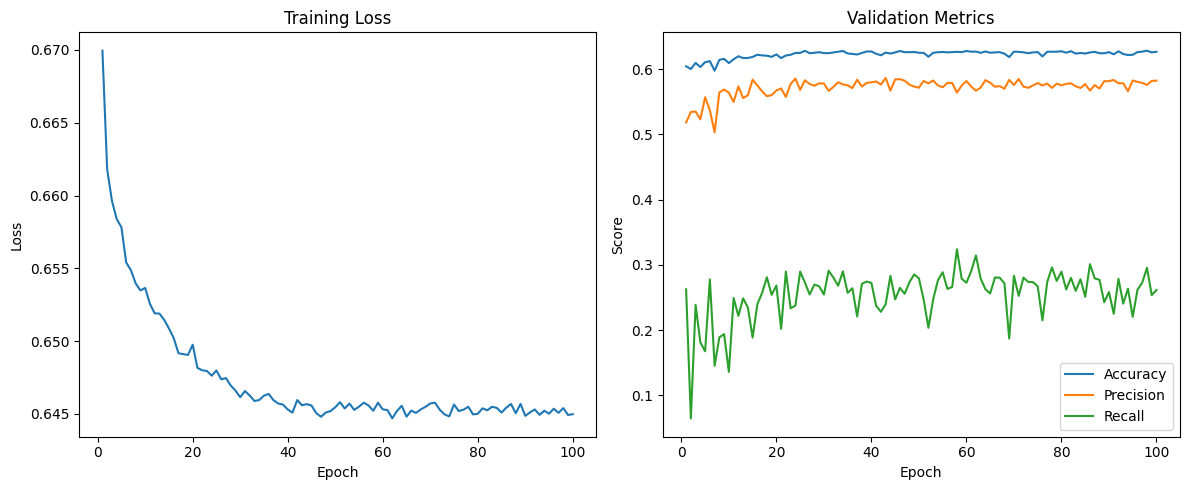

In [26]:
# Main testing sequence

# Load data frame using import function w/ 2015 data
data_frame, feature_cols, target_cols = data_import(include_target=True, year=2015)
data_frame = data_frame.sample(frac=1.0, random_state=42).reset_index(drop=True)

# Training parameters
n_train = int(0.8*len(data_frame))
df_train = data_frame[:n_train]
df_val = data_frame[n_train:]

# Use torch data class
train_dataset = NYISOData(df_train, feature_cols, target_cols)
val_dataset = NYISOData(df_val, feature_cols, target_cols)

# Set batch size and loaders
batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size)

# Initialize device, model, loss criterion, learning rate, optimizer
JacobNet_i = JacobNet(input_dim=len(feature_cols)).to(device)

# Print total number of paramaters of model
total_params = sum(p.numel() for p in JacobNet_i.parameters())
print(f"JacobNet Total Parameter Count: {total_params}")

# Pick loss criterion, learning rate, optimizer, scheduler
criterion = nn.BCELoss()
learning_rate = 1e-4
optimizer = optim.Adam(JacobNet_i.parameters(), lr=learning_rate)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

# Arrays for plotting
train_losses = []
accuracies = []
precisions = []
recalls = []

# Training epoch loop
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Deplying JacobNet on {device} architecture for training.")
epochs = 100
for epoch in range(epochs):
    #print(f"\nEpoch {epoch+1}/{epochs}")

    loss = train(JacobNet_i, train_loader, optimizer, criterion, device, epoch, epochs)
    scheduler.step()

    acc, prec, rec = evaluate(JacobNet_i, val_loader, device)

    train_losses.append(loss)
    accuracies.append(acc)
    precisions.append(prec)
    recalls.append(rec)

    #print(f"Loss={loss:.4f} | Acc={acc:.4f} | Prec={prec:.4f} | Rec={rec:.4f} | Thresh={current_threshold:.3f}")

# Save trained model weights
torch.save(JacobNet_i.state_dict(), "weights/jacobnet_trained_weights.pth")
print("JacobNet weights saved.")

# Plot model training/validation metrics
print("JacobNet Training Plots:")
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(range(1, epochs+1), train_losses)
plt.title('Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.subplot(1, 2, 2)
plt.plot(range(1, epochs+1), accuracies, label='Accuracy')
plt.plot(range(1, epochs+1), precisions, label='Precision')
plt.plot(range(1, epochs+1), recalls, label='Recall')
plt.title('Validation Metrics')
plt.xlabel('Epoch')
plt.ylabel('Score')
plt.legend()

plt.tight_layout()
plt.show()

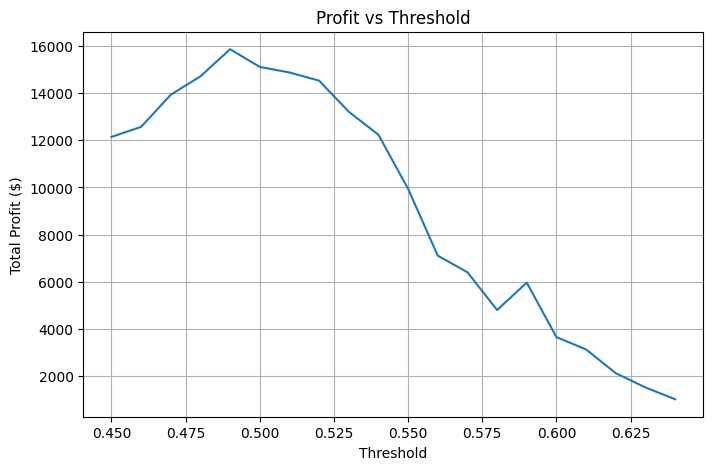

Highest Profit: $15856.91 (at Confidence Threshold: 0.49)


Prediction file saved.
Total_Profit: 15856.91


In [ ]:
# Test model on 2016 data
# device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
# print(f"Device: {device}")
JacobNet_tester = JacobNet(input_dim=len(feature_cols)).to(device)
JacobNet_tester.load_state_dict(torch.load("weights/jacobnet_trained_weights.pth"))
JacobNet_tester.eval()

# Load 2016 data for predicting
test_data2016, feature_cols2016, _ = data_import(include_target=False, year=2016)
# print(test_data2016)

best_profit, best_threshold = optimal_threshold(JacobNet_tester, test_data2016, device, feature_cols)

# Print total profit at best threshold
# print(f"Total_Profit: {bidding_sim(test_data2016, JacobNet_tester, feature_cols2016, device, bid_threshold=best_threshold, output=True):.2f}")
